In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Fixing TotalCharges column
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(inplace=True)

# Quick look at the data
print("Shape:", df.shape)
print("\nFirst 3 rows:")
df.head(3)

Shape: (7032, 21)

First 3 rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


In [24]:
# Finding 1: Overall churn rate

# % of customers are churning
churn_rate = (df['Churn'] == 'Yes').mean() * 100
print(f"Overall churn rate: {churn_rate:.1f}%")

# Quick count
print(df['Churn'].value_counts())

Overall churn rate: 26.6%
Churn
No     5163
Yes    1869
Name: count, dtype: int64


/tmp/ipykernel_26384/3325114795.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  contract_churn = df.groupby('Contract').apply(
/tmp/ipykernel_26384/3325114795.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


         Contract  Churn_Rate_Pct
0  Month-to-month       42.709677
1        One year       11.277174
2        Two year        2.848665


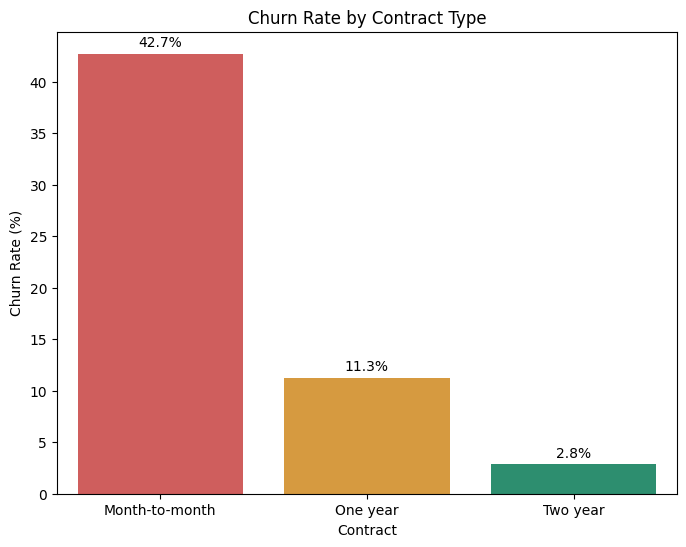

In [25]:
# Finding 2: Churn by contract type

# Churn rate broken down by contract type
contract_churn = df.groupby('Contract').apply(
    lambda x: (x['Churn'] == 'Yes').mean() * 100
).reset_index()
contract_churn.columns = ['Contract', 'Churn_Rate_Pct']
print(contract_churn)

# Bar chart
fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(
    data=contract_churn,
    x='Contract',
    y='Churn_Rate_Pct',
    palette=['#E24B4A', '#EF9F27', '#1D9E75'],
    ax=ax
    )

ax.set_title('Churn Rate by Contract Type')
ax.set_ylabel('Churn Rate (%)')

for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f'{height:.1f}%',
        (p.get_x() + p.get_width() / 2, height),
        ha='center',
        va='bottom',
        fontsize=10,
        xytext=(0, 3),
        textcoords='offset points'
    )

plt.savefig('churn_by_contract.png', dpi=150, bbox_inches='tight')
plt.show()

In [26]:
# Finding 3: Revenue at risk

# How much revenue are we losing to churned customers?
churned = df[df['Churn'] == 'Yes']
at_risk = churned['TotalCharges'].sum()
total = df['TotalCharges'].sum()

print(f"Revenue at risk : ${at_risk:,.0f}")
print(f"Total revenue   : ${total:,.0f}")
print(f"Percentage lost : {at_risk/total*100:.1f}%")

Revenue at risk : $2,862,927
Total revenue   : $16,056,169
Percentage lost : 17.8%


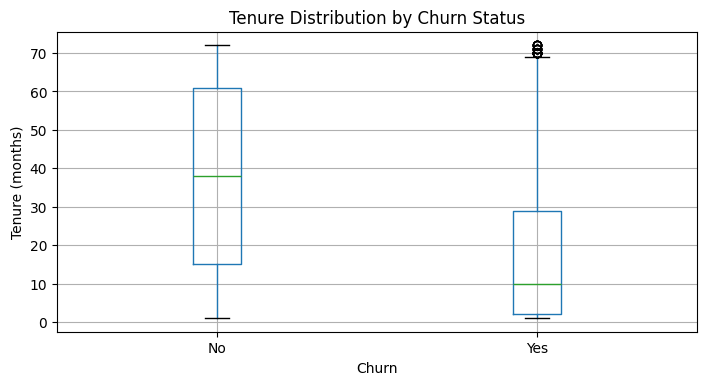

In [27]:
# Finding 4: Tenure by churn group

# Do customers who churn have shorter tenure?
fig, ax = plt.subplots(figsize=(8, 4))
df.boxplot(column='tenure', by='Churn', ax=ax)

ax.set_title('Tenure Distribution by Churn Status')
ax.set_xlabel('Churn')
ax.set_ylabel('Tenure (months)')
plt.suptitle('')  # removes default extra title

plt.savefig('tenure_churn.png', dpi=150, bbox_inches='tight')
plt.show()



/tmp/ipykernel_26384/3387301394.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  internet_churn = df.groupby('InternetService').apply(
/tmp/ipykernel_26384/3387301394.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


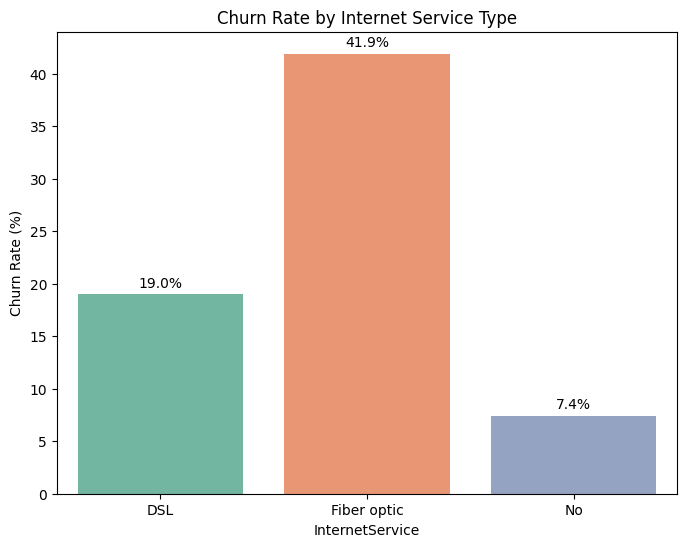

In [31]:
# Finding 5: Churn by Internet Service

internet_churn = df.groupby('InternetService').apply(
    lambda x: (x['Churn'] == 'Yes').mean() * 100
).reset_index()

internet_churn.columns = ['InternetService', 'Churn_Rate_Pct']

fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(
    data=internet_churn,
    x='InternetService',
    y='Churn_Rate_Pct',
    palette='Set2',
    ax=ax
    )

ax.set_title('Churn Rate by Internet Service Type')
ax.set_ylabel('Churn Rate (%)')

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3)

plt.savefig('churn_by_internet.png', dpi=150, bbox_inches='tight')
plt.show()


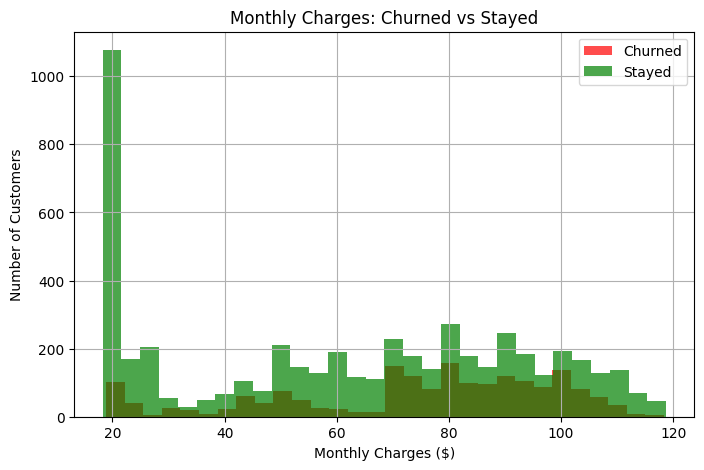

In [36]:
# Finding 6: Monthly Charges Distribution

# Do high-paying customers churn more?
fig, ax = plt.subplots(figsize=(8, 5))

df[df['Churn'] == 'Yes']['MonthlyCharges'].hist(
    bins=30, alpha=0.7, label='Churned', color='red', ax=ax)

df[df['Churn'] == 'No']['MonthlyCharges'].hist(
    bins=30, alpha=0.7, label='Stayed', color='green', ax=ax)

ax.set_title('Monthly Charges: Churned vs Stayed')
ax.set_xlabel('Monthly Charges ($)')
ax.set_ylabel('Number of Customers')
ax.legend()

plt.savefig('monthly_charges_churn.png', dpi=150, bbox_inches='tight')
plt.show()

/tmp/ipykernel_26384/1193108123.py:19: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  cohort_churn = df.groupby('tenure_group').apply(
/tmp/ipykernel_26384/1193108123.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cohort_churn, x='Tenure Group', y='Churn_Rate_Pct',


   Tenure Group  Churn_Rate_Pct
0   0–12 months       47.678161
1  13–24 months       28.710938
2  25–48 months       20.388959
3    49+ months        9.513176


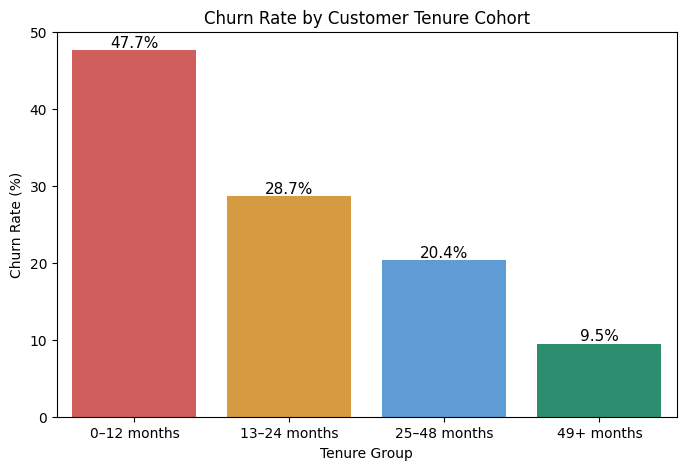

In [37]:
# Finding 7: Churn by Tenure Cohort

# Create tenure groups
def tenure_group(t):
    if t <= 12:
        return '0–12 months'
    elif t <= 24:
        return '13–24 months'
    elif t <= 48:
        return '25–48 months'
    else:
        return '49+ months'

df['tenure_group'] = df['tenure'].apply(tenure_group)

# Order them properly
tenure_order = ['0–12 months', '13–24 months', '25–48 months', '49+ months']

cohort_churn = df.groupby('tenure_group').apply(
    lambda x: (x['Churn'] == 'Yes').mean() * 100
).reindex(tenure_order).reset_index()
cohort_churn.columns = ['Tenure Group', 'Churn_Rate_Pct']

print(cohort_churn)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=cohort_churn, x='Tenure Group', y='Churn_Rate_Pct',
            palette=['#E24B4A', '#EF9F27', '#4C9BE8', '#1D9E75'],
            order=tenure_order)
ax.set_title('Churn Rate by Customer Tenure Cohort')
ax.set_ylabel('Churn Rate (%)')
ax.set_xlabel('Tenure Group')
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11)
plt.savefig('churn_by_tenure_cohort.png', dpi=150, bbox_inches='tight')
plt.show()

/tmp/ipykernel_26384/2362416772.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  service_churn = df.groupby('num_services').apply(


   Num Services  Churn_Rate_Pct
0             1       10.952381
1             2       31.038506
2             3       44.917258
3             4       36.476684
4             5       31.378936
5             6       25.607064
6             7       22.551929
7             8       12.405063
8             9        5.288462


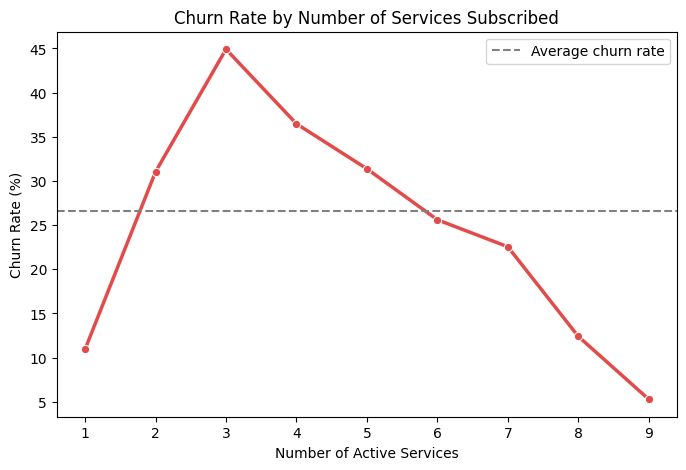

In [38]:
# Finding 8: Churn by Number of Services

# Create a count of how many services each customer has
service_cols = ['PhoneService', 'MultipleLines', 'InternetService',
                'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                'TechSupport', 'StreamingTV', 'StreamingMovies']

# Count non-'No' values as active services
df['num_services'] = df[service_cols].apply(
    lambda row: sum(v not in ['No', 'No internet service',
                              'No phone service'] for v in row), axis=1)

service_churn = df.groupby('num_services').apply(
    lambda x: (x['Churn'] == 'Yes').mean() * 100
).reset_index()
service_churn.columns = ['Num Services', 'Churn_Rate_Pct']

print(service_churn)

fig, ax = plt.subplots(figsize=(8, 5))
sns.lineplot(data=service_churn, x='Num Services', y='Churn_Rate_Pct',
             marker='o', color='#E24B4A', linewidth=2.5)
ax.set_title('Churn Rate by Number of Services Subscribed')
ax.set_ylabel('Churn Rate (%)')
ax.set_xlabel('Number of Active Services')
ax.axhline(y=df['Churn'].eq('Yes').mean()*100,
           color='gray', linestyle='--', label='Average churn rate')
ax.legend()
plt.savefig('churn_by_services.png', dpi=150, bbox_inches='tight')
plt.show()

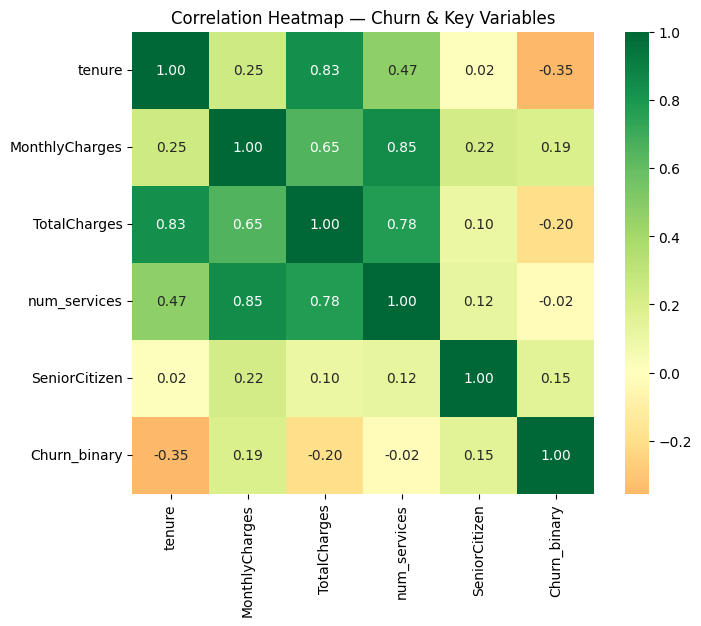


Correlation with Churn:
tenure           -0.354049
TotalCharges     -0.199484
num_services     -0.019644
SeniorCitizen     0.150541
MonthlyCharges    0.192858
Churn_binary      1.000000
Name: Churn_binary, dtype: float64


In [39]:
# Finding 9: Correlation Heatmap

# Selecting only numeric columns for correlation
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges',
                'num_services', 'SeniorCitizen']

# Add binary churn for correlation
df['Churn_binary'] = (df['Churn'] == 'Yes').astype(int)

corr = df[numeric_cols + ['Churn_binary']].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, square=True, ax=ax)
ax.set_title('Correlation Heatmap — Churn & Key Variables')
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nCorrelation with Churn:")
print(corr['Churn_binary'].sort_values())